Scanning cohort for AIM markups...


Patients Checked: 100%|██████████| 211/211 [26:45<00:00,  7.61s/it] 


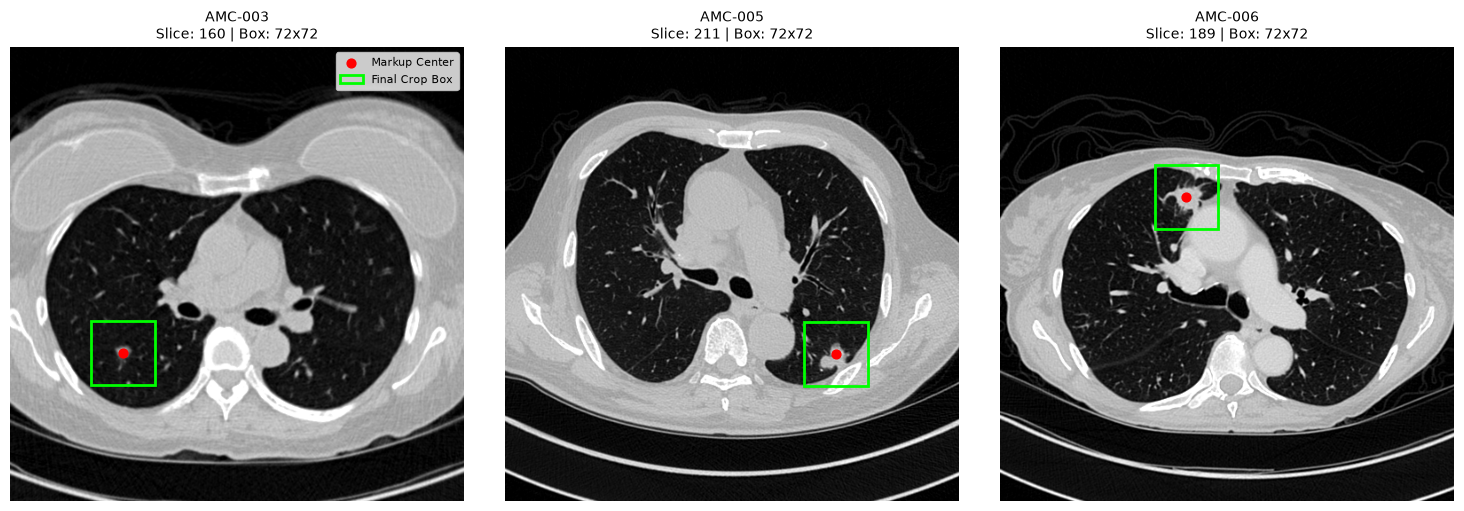


=== GLOBAL RESOLUTION RESULTS ===
Exact SOP Matches (Resolved): 185
Frame-Number Fallbacks:       6
Totally Unresolved:           0


In [ ]:
# %% [markdown]
# # AIM Global Resolution Sandbox (Optimized & Fast)
# Visually verifies that our global SOPInstanceUID search correctly maps radiologist 
# XML markups to the exact DICOM series and slice, and scales the coordinates properly.

# %%
import os, glob, math
import xml.etree.ElementTree as ET
import numpy as np, pandas as pd
import pydicom, SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x

# --- PATHS ---
DATA_ROOT = Path("data/nsclc_radiogenomics")
AIM_DIR   = Path("data/AIM_files_updated-11-10-2020/AIM_files_updated-11-10-2020")
CLINICAL_CSV = Path("data/NSCLCR01Radiogenomic_DATA_LABELS_2018-05-22_1500-shifted.csv")

# --- 1. PARSER ---
def _local(t): return t.rsplit('}', 1)[-1]

def parse_aim_markup(xml_path):
    out = []
    try: root = ET.parse(xml_path).getroot()
    except Exception: return out
    for me in root.iter():
        if _local(me.tag) != "MarkupEntity": continue
        sop = None; frame = None; pts = []
        for el in me.iter():
            lt = _local(el.tag)
            if lt == "imageReferenceUid": sop = el.get("root")
            elif lt == "referencedFrameNumber": frame = el.get("value")
            elif lt == "TwoDimensionSpatialCoordinate":
                x = y = None
                for c in el:
                    if _local(c.tag) == "x": x = float(c.get("value"))
                    if _local(c.tag) == "y": y = float(c.get("value"))
                if x is not None and y is not None: pts.append((x, y))
        if pts: out.append({"sop": sop, "frame": int(frame) if frame else None, "xy": pts})
    return out

# --- 2. FAST GLOBAL SEARCH ---
def find_series_for_sops(pdir, target_sops):
    """Fast scan: Peek at DICOM headers to find which directory contains our target SOPs."""
    found_dirs = {}
    for root, _, files in os.walk(pdir):
        if len(found_dirs) == len(target_sops): break # Found them all
        
        dcms = [f for f in files if f.lower().endswith(".dcm")]
        if not dcms: continue
        
        # Check if it's a CT series
        try:
            test_ds = pydicom.dcmread(os.path.join(root, dcms[0]), stop_before_pixels=True, force=True)
            if str(getattr(test_ds, "Modality", "")).upper() != "CT": continue
        except Exception: continue
        
        # Scan headers in this CT series
        for dcm in dcms:
            try:
                ds = pydicom.dcmread(os.path.join(root, dcm), stop_before_pixels=True, force=True)
                uid = str(getattr(ds, 'SOPInstanceUID', ''))
                if uid in target_sops:
                    found_dirs[uid] = root
            except Exception: pass
    return found_dirs

# --- 3. EXECUTE & VISUALIZE ---
clin = pd.read_csv(CLINICAL_CSV)
clin["Case ID"] = clin["Case ID"].astype(str).str.strip()

all_aim_files = glob.glob(os.path.join(str(AIM_DIR), "*.xml"))
if not all_aim_files:
    print("No AIM XMLs found. Check path.")

success_count = 0
fallback_count = 0
unresolved_count = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_idx = 0

print("Scanning cohort for AIM markups...")

# Wrapped in TQDM to show live progress
for cid in tqdm(clin["Case ID"], desc="Patients Checked"):
    aim_file = [f for f in all_aim_files if cid in os.path.basename(f)]
    if not aim_file: continue
    
    markups = parse_aim_markup(aim_file[0])
    if not markups: continue
    
    pdir = DATA_ROOT / cid
    if not pdir.exists(): continue
    
    # 1. Fast scan to find the exact directories holding the SOPs
    target_sops = {mk["sop"] for mk in markups if mk["sop"]}
    sop_to_dir = find_series_for_sops(pdir, target_sops)
    
    for mk in markups:
        sop, frame, pts = mk["sop"], mk["frame"], mk["xy"]
        
        if sop in sop_to_dir:
            success_count += 1
            
            if plot_idx < 3:
                series_dir = sop_to_dir[sop]
                r = sitk.ImageSeriesReader()
                sitk_files = r.GetGDCMSeriesFileNames(series_dir)
                
                z_idx = 0
                cols, rows = 512, 512
                for z, fp in enumerate(sitk_files):
                    ds = pydicom.dcmread(fp, stop_before_pixels=True, force=True)
                    if str(getattr(ds, 'SOPInstanceUID', '')) == sop:
                        z_idx = z
                        cols = getattr(ds, 'Columns', 512)
                        rows = getattr(ds, 'Rows', 512)
                        break
                
                r.SetFileNames(sitk_files)
                target_arr = sitk.GetArrayFromImage(r.Execute())
                cur_Z, cur_Y, cur_X = target_arr.shape
                
                scale_x = cur_X / float(cols) if cols else 1.0
                scale_y = cur_Y / float(rows) if rows else 1.0
                
                cx, cy = pts[0][0] * scale_x, pts[0][1] * scale_y
                
                # --- THE FIX: Enforce a minimum radius and calculate the exact crop box ---
                raw_radius = math.hypot((pts[1][0]*scale_x)-cx, (pts[1][1]*scale_y)-cy) if len(pts) >= 2 else 25.0
                safe_radius = max(raw_radius, 20.0) # Never go smaller than 20 pixels
                
                CROP_PAD_VOX = 16
                half = int(round(safe_radius)) + CROP_PAD_VOX
                
                # Bounding box bottom-left coordinates for matplotlib
                box_x0 = cx - half
                box_y0 = cy - half
                box_width = half * 2
                
                ax = axes[plot_idx]
                ax.imshow(target_arr[z_idx], cmap="gray", vmin=-1000, vmax=400)
                ax.scatter([cx], [cy], color='red', s=40, label="Markup Center")
                
                # Draw the actual square crop area
                rect = patches.Rectangle((box_x0, box_y0), box_width, box_width, 
                                         linewidth=2, edgecolor='lime', facecolor='none', label="Final Crop Box")
                ax.add_patch(rect)
                
                ax.set_title(f"{cid}\nSlice: {z_idx} | Box: {box_width}x{box_width}", fontsize=10)
                ax.axis('off')
                if plot_idx == 0: ax.legend(loc="upper right", fontsize=8)
                
                plot_idx += 1
                
        elif frame is not None:
            fallback_count += 1
        else:
            unresolved_count += 1

plt.tight_layout()
plt.show()

print(f"\n=== GLOBAL RESOLUTION RESULTS ===")
print(f"Exact SOP Matches (Resolved): {success_count}")
print(f"Frame-Number Fallbacks:       {fallback_count}")
print(f"Totally Unresolved:           {unresolved_count}")